In [1]:
import pandas as pd
import numpy as np
#from config_ import *

named13C_cellulose = "δ13C (‰ v.s.V-PDB)" ### Exceptional 
named13C_bulk = "bulk_δ13C (‰ v.s.V-PDB)"
name18O = "δ18O in ‰ vs DeltaSMOW"
named15N = "δ15N (‰ v.s. V-PDB)"
nameC_bulk ="[C_b]%"
nameC_cellulose = "[C]%"
thick = "mean_thickness_(mm)"
though = "mean_toughness_(kN/m)"
LA = "Leaf area (cm²)"
name = "genus" + "especie"

Galeras Cleaning

base_grandes =

rasgos =

#unir estas dos primero y tener unificado, asegurandonos que estamos bien
#unir con cellulosa y bulk



In [2]:
base_grande = pd.read_excel(r"\Users\selene.baez\Downloads\NAPO_preliminar\Galeras\Base_Galeras_vK.xlsx")
rasgos = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Galeras\03. Rasgos Galeras.xlsx")
#en rasgos solo mantener las columnas de los rasgos. 
rasgos = rasgos.rename(columns={"#":"Plot", "TreeID_2025":"TreeID"}) #Nunca usar Familia y genus de este.



In [3]:
merge = pd.merge(base_grande, rasgos, how="outer", left_on = ["new ID 2024","Plot"],right_on= ["TreeID","Plot"])
merge = merge[merge["PlotID"].isin([
    "GAL_22", "GAL_23", "GAL_24", "GAL_28",
    "GAL_48", "GAL_50", "GAL_60", "GAL_62", "GAL_29"
])] #filtra los censados. GAL 29 no hecha pero hay del 2006

#merge.to_excel("testGaleras.xlsx")

# Resultados Julio 2025

In [4]:
#CELLULOSA
celulosa = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Galeras\resultados072025.xlsx")
patrones = ["p60", "p62", "p22","p23","p24","p28","p48","p50","p29"]
df_filtrado = celulosa[celulosa["Sample ID"].str.contains("|".join(patrones), na=False)]
## arreglando typos
df_filtrado["Sample ID"] = df_filtrado["Sample ID"].replace({
    "p28-8974": "p23-8974",
    "p28-8982": "p23-8982",
    "p28-8976": "p23-8976"})

df_filtrado["Year"] = np.select(
    [
        df_filtrado["Meas batch"].str.contains("NAPO2006", na=False),
        df_filtrado["Meas batch"].str.contains("NUMEX", na=False), #caso especial
        df_filtrado["Meas batch"].str.contains("NAPO2025", na=False),
    ],
    [2006,2006,2025],
    default=np.nan
)

import numpy as np
#HELP: La idea es filtrar y luego de filtrar por año se puede unir por ID 2025 o ID original
df_filtrado[["Plot","TreeID"]] = df_filtrado["Sample ID"].str.split("-",expand=True)
df_filtrado["Type"] = "leaf pulverized"
df_filtrado["Plot"]= df_filtrado["Plot"].str.replace("p","")
df_filtrado= df_filtrado.drop(columns={"Meas batch","Comment","Plot"})

def homogeneizar_ID(df):
  df["old_treeID"] = np.where(df["Year"] == 2006, df["TreeID"], np.nan)
  df["new_TreeID"] = np.where(df["Year"] == 2025, df["TreeID"], np.nan)
  return  df

df_filtrado = df_filtrado.rename(columns = {"δ15N (‰ v.s. AIR)":named13C_cellulose,"[C] in %":nameC_cellulose})
#df_filtrado = homogeneizar_ID(df_filtrado)
print("Resultados de Celulosa")
df_filtrado= df_filtrado.drop(columns = {"TreeID","Year"})

len(df_filtrado) #78
df_filtrado


Resultados de Celulosa


C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16960\2272036324.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["Sample ID"] = df_filtrado["Sample ID"].replace({
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16960\2272036324.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["Year"] = np.select(
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16960\2272036324.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

,Sample ID,[C]%,δ13C (‰ v.s.V-PDB),Type
78,p23-557,0.455530,-29.289590,leaf pulverized
80,p22-550,0.474114,-29.723659,leaf pulverized
95,p23-561,43.689971,-31.626469,leaf pulverized
96,p29-763,48.003020,-32.797394,leaf pulverized
97,p29-768,43.306540,-29.511927,leaf pulverized
...,...,...,...,...
268,p60-8774,43.326518,-29.333433,leaf pulverized
269,p60-8763,43.478149,-28.901935,leaf pulverized
270,p60-8751,43.998552,-27.759220,leaf pulverized
271,p28-8738,43.841439,-32.261144,leaf pulverized


In [5]:

SEQ1= pd.read_excel("Andrea_bulk CN_2025.xlsx",sheet_name="SEQ1")
SEQ1["Year"] = 2006
SEQ2 = pd.read_excel("Andrea_bulk CN_2025.xlsx",sheet_name="SEQ2")
SEQ2["Year"] = 2006
SEQ4 = pd.read_excel("Andrea_bulk CN_2025.xlsx",sheet_name="SEQ4")
SEQ4["Year"] = 2025
SEQ5 = pd.read_excel("Andrea_bulk CN_2025.xlsx",sheet_name="SEQ5")
SEQ5["Year"] = 2025
SEQ7 = pd.read_excel("Andrea_bulk CN_2025.xlsx",sheet_name="SEQ7")
SEQ7["Year"] = 2006

bulk = pd.concat([SEQ1,SEQ2,SEQ4,SEQ5,SEQ7])
bulk = bulk.rename(columns={"certified values":"sample-ID", "Unnamed: 2":"[N]",
                            "Unnamed: 4":nameC_bulk,"Unnamed: 6":named15N,
                            "Unnamed: 8":named13C_bulk,"[C] in %":named13C_cellulose})


bulk[["Plot","TreeID","add"]] =bulk["sample-ID"].str.split("-",expand=True) #len 182
columns_drop = ["Unnamed: 0", "Unnamed: 3","Unnamed: 5","Unnamed: 7", "Unnamed: 9","Unnamed: 10","Unnamed: 11","Unnamed: 12"]
bulk = bulk.drop(columns=columns_drop)
patrones = ["p60", "p62", "p22","p23","p24","p28","p48","p50","p29"]
df_filtrado_bulk = bulk[bulk["sample-ID"].str.contains("|".join(patrones), na=False)]
df_filtrado_bulk = df_filtrado_bulk.drop(columns = {"add"})
df_filtrado_bulk = homogeneizar_ID(df_filtrado_bulk)
df_filtrado_bulk

,sample-ID,[N],[C_b]%,δ15N (‰ v.s. V-PDB),bulk_δ13C (‰ v.s.V-PDB),Year,Plot,TreeID,old_treeID,new_TreeID
18,p22-522,0.026297,0.413892,4.52,-30.8,2006,p22,522,522,NaN
19,p22-525,0.014931,0.449723,2.14,-30.33,2006,p22,525,525,NaN
20,p22-535,0.023597,0.473618,2.76,-31.05,2006,p22,535,535,NaN
21,p22-537,0.023649,0.48774,-0.98,-31.22,2006,p22,537,537,NaN
22,p22-538,0.021715,0.443533,1.37,-32.59,2006,p22,538,538,NaN
...,...,...,...,...,...,...,...,...,...,...
55,p29-777,0.020353,0.465026,0.910612,-30.928973,2006,p29,777,777,NaN
56,p29-779,0.027024,0.456031,4.883287,-32.268307,2006,p29,779,779,NaN
57,p29-781,0.030355,0.443805,1.769842,-33.762179,2006,p29,781,781,NaN
58,p29-792,0.017992,0.385438,1.274521,-33.113117,2006,p29,792,792,NaN


In [6]:
merged_cellulosa_bulk = pd.merge(df_filtrado, df_filtrado_bulk,left_on="Sample ID", right_on="sample-ID",how= "outer")
len(merged_cellulosa_bulk) #82

merged_cellulosa_bulk#.to_excel("test.xlsx")

## dilema old_treeID ###HELP here for Plot, some samples dont gent the plot

,Sample ID,[C]%,δ13C (‰ v.s.V-PDB),Type,sample-ID,[N],[C_b]%,δ15N (‰ v.s. V-PDB),bulk_δ13C (‰ v.s.V-PDB),Year,Plot,TreeID,old_treeID,new_TreeID
0,p23-557,0.455530,-29.289590,leaf pulverized,p23-557,0.019124,0.485531,1.960678,-31.458731,2006.0,p23,557,557,NaN
1,p23-557,43.360479,-29.427788,leaf pulverized,p23-557,0.019124,0.485531,1.960678,-31.458731,2006.0,p23,557,557,NaN
2,p22-550,0.474114,-29.723659,leaf pulverized,p22-550,0.02523,0.465053,4.37,-30.31,2006.0,p22,550,550,NaN
3,p22-550,47.207712,-29.723923,leaf pulverized,p22-550,0.02523,0.465053,4.37,-30.31,2006.0,p22,550,550,NaN
4,p23-561,43.689971,-31.626469,leaf pulverized,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,p60-8885,46.225205,-33.253234,leaf pulverized,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,NaN,NaN,NaN,NaN,p23-565,0.020259,0.453534,0.210098,-33.004256,2006.0,p23,565,565,NaN
79,NaN,NaN,NaN,NaN,p23-578,0.027313,0.424881,1.411476,-32.665238,2006.0,p23,578,578,NaN
80,NaN,NaN,NaN,NaN,p23-566,0.018864,0.445698,-0.595568,-32.391937,2006.0,p23,566,566,NaN


# Celulosa de muestras de herbario y muestras enero 2026.

In [7]:
cel2026 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea-Cellulose-13C-202603.xlsx")
cel2026["Sample-ID"] = cel2026["Sample-ID"].replace({"3872":"jh-3872","3896":"jh-3896","3885":"jh-3885","jh3697":"jh-3697","jh3621":"jh3621"}) ### REVISAR
cel2026[["Plot","numeroCampo"]] = cel2026["Sample-ID"].str.split("-",expand=True) #aplica para los que sean herbario
cel2026["Plot"] = cel2026["Plot"].str.replace("p","")
cel2026.loc[cel2026["Plot"] != "jh", "Type"] = "leaf pulverized"
cel2026.loc[cel2026["Plot"] != "jh", "Year"] = 2025
cel2026.loc[cel2026["Plot"] == "jh", "Type"] = "leaf herbarium"
cel2026.loc[cel2026["Plot"] == "jh", "Year"] = 2006
cel2026["numeroCampo"] = cel2026["numeroCampo"].astype("float64")
cel2026 = cel2026.drop(columns={"nr of samples","Batch"})
cel2026 = cel2026.rename(columns={"[C] m/m in %":nameC_cellulose,"δ13C (‰ v.s. V-PDB)":named13C_cellulose})


In [8]:
### Cleaning of the new cellulose results. 
### work only with pulverized samples ####
pulv2026 = cel2026[cel2026["Type"] == "leaf pulverized"] ##99
pulv2026 [["Plot","new_TreeID"]] = pulv2026["Sample-ID"].str.split("-",expand=True)
pulv2026["Plot"]= pulv2026["Plot"].str.replace("p","") #homogeneizar
patrones = ["60", "62", "22","23","24","28","48","50","29"]
regex = r"p(" + "|".join(patrones) + r")\b"
pulv2026Gal = pulv2026[pulv2026["Sample-ID"].str.contains(regex, na=False)] #OK
    
### only working with samples 2006 jh herbarium ##
herb_2006 = cel2026[cel2026["Type"] == "leaf herbarium"] ##99
herb = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Jürgen herbarium\QCA_GOET.xlsx")
herb = herb[["numeroCampo","description"]] # se saca los numeros de los arboles
herb = herb.drop_duplicates(subset="numeroCampo")
herb_2006["numeroCampo"] = herb_2006["numeroCampo"].astype("float64")
herb["numeroCampo"] = herb["numeroCampo"].astype("float64")

cel2026_herb = pd.merge(herb_2006,herb,left_on="numeroCampo",right_on="numeroCampo", how ="left")
cel2026_herb[["Plot_","TreeID_herb"]]= cel2026_herb["description"].str.split("#",expand=True)
cel2026_herb[["old_treeID","comment","comment2"]]= cel2026_herb["TreeID_herb"].str.split(",",expand=True)
cel2026_herb["Plot"]= cel2026_herb["Plot_"].str.replace("plot","").combine_first(cel2026_herb["Plot"])
cel2026_herb = cel2026_herb.drop(columns={"comment","comment2","TreeID_herb"}) ### Plot that are JH look for them somewhere.

patrones = ["60", "62", "22","23","24","28","48","50","29"] #Galeras
#regex = r"p(" + "|".join(patrones) + r")\b"
herb_galeras = cel2026_herb[cel2026_herb["Plot"].str.contains("|".join(patrones), na=False)]



C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16960\1489799954.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pulv2026 [["Plot","new_TreeID"]] = pulv2026["Sample-ID"].str.split("-",expand=True)
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16960\1489799954.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pulv2026 [["Plot","new_TreeID"]] = pulv2026["Sample-ID"].str.split("-",expand=True)
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16960\1489799954.py:5: SettingWithCopyWarning: 
A value 

# Ultima placa de celulosa con multiples muestras
Miscelanea

In [ ]:
mis2026 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Report 13C-pq4.xlsx")
#cel2026["Sample-ID"] = cel2026["Sample-ID"].replace({"3872":"jh-3872","3896":"jh-3896","3885":"jh-3885","jh3697":"jh-3697","jh3621":"jh3621"}) ### REVISAR
mis2026 = mis2026.rename(columns={"Sample ID":"Sample-ID"})#arriba todo con guion
mis2026 = mis2026.rename(columns={"[C] m/m":nameC_cellulose,"δ13C (‰ v.s. V-PDB)":named13C_cellulose})

patrones = ["60", "62", "20","22","23","24","28","48","50","29"]
regex = r"p(" + "|".join(patrones) + r")\b"
mis2026 = mis2026[mis2026["Sample-ID"].str.contains(regex, na=False)] #Filtremos solo Galeras
mis2026.loc[mis2026["Sample-ID"].str.contains("jh"), "Type"] = "leaf herbarium"
mis2026.loc[mis2026["Sample-ID"].str.contains("jh"), "Year"] = "2006"
mis2026.loc[~mis2026["Sample-ID"].str.contains("jh"), "Type"] = "leaf pulverized"

#separamos los resultados del herbario para añadir informacion
misjh = mis2026[mis2026["Type"]== "leaf herbarium"][["Sample-ID",nameC_cellulose,named13C_cellulose,"Type","Year"]]
misjh[["Type 2","Plot","numeroCampo"]]= misjh["Sample-ID"].str.split("-",expand=True)
misjh["numeroCampo"] = misjh["numeroCampo"].astype("float64")
misjh_herb = pd.merge(misjh,herb,left_on="numeroCampo",right_on="numeroCampo", how ="left")
misjh_herb["old_treeID"] = misjh_herb["description"].str.extract(r"#\s*(\d+)")
misjh_herb["Type 2"] = "Miscelanea" #para verificar q si funciona

#### separamos los de parcelas
mis_cel = mis2026[mis2026["Type"]== "leaf pulverized"][["Sample-ID",nameC_cellulose,named13C_cellulose,"Type"]]#Year, quiero revisar
mis_cel[["Plot","TreeID"]]= mis_cel["Sample-ID"].str.split("-",expand=True)
mis_cel #asignar  9 muestral manualmente los años. Creo que del 23 y 29 son del 2006 o cualquier otro año.
year_dict = {
    "p23-566": 2006,
    "p23-578": 2006,
    "p29-792": 2006,
    "p23-565": 2006,
    "p23-560": 2006,
    "p48-8666": 2025,
    "p48-3698": 2025,
    "p23-8980": 2025,
    "p28-8974":2025
}
mis_cel["Year"] = mis_cel["Sample-ID"].map(year_dict)
mis_cel.loc[mis_cel["Year"] == 2006, "old_treeID"] = mis_cel["TreeID"]
mis_cel.loc[mis_cel["Year"] == 2025, "new_TreeID"] = mis_cel["TreeID"]
mis_cel ### FALTAN MUESTRS DEL PLOT 20

C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16960\2442825812.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mis2026 = mis2026[mis2026["Sample-ID"].str.contains(regex, na=False)] #Filtremos solo Galeras


,Sample-ID,[C]%,δ13C (‰ v.s.V-PDB),Type,Plot,TreeID,Year,old_treeID,new_TreeID
10,p23-566,0.4499,-32.80,leaf pulverized,p23,566,2006.0,566,NaN
12,p23-578,0.3496,-30.42,leaf pulverized,p23,578,2006.0,578,NaN
14,p29-792,0.3766,-32.34,leaf pulverized,p29,792,2006.0,792,NaN
15,p48-8666,0.4249,-31.49,leaf pulverized,p48,8666,2025.0,NaN,8666
22,p23-565,0.4368,-32.44,leaf pulverized,p23,565,2006.0,565,NaN
24,p48-3698,0.4193,-27.79,leaf pulverized,p48,3698,2025.0,NaN,3698
75,p23-8980,0.2728,-28.17,leaf pulverized,p23,8980,2025.0,NaN,8980
80,p20-495,0.4012,-29.90,leaf pulverized,p20,495,NaN,NaN,NaN
82,p28-8974,0.4054,-29.37,leaf pulverized,p28,8974,2025.0,NaN,8974
85,p23-560,0.3961,-30.10,leaf pulverized,p23,560,2006.0,560,NaN


In [10]:
#### con la miscelanea ###
results_2026 = pd.concat([herb_galeras,pulv2026Gal,misjh_herb,mis_cel])
results_2026 = results_2026.rename(columns={"Sample-ID":"Sample ID"})

results_2026 #HELP Creo que se pueden eliminar ciertas columnas que tienen inmformacion q nada que ver. 

,Sample ID,[C]%,δ13C (‰ v.s.V-PDB),Plot,numeroCampo,Type,Year,description,Plot_,old_treeID,new_TreeID,Type 2,TreeID
0,jh-3621,45.865248,-31.089083,50,3621.0,leaf herbarium,2006.0,plot 50#1465,plot 50,1465,NaN,NaN,NaN
1,jh-3657,47.252744,-30.354804,60,3657.0,leaf herbarium,2006.0,plot 60#1813,plot 60,1813,NaN,NaN,NaN
4,jh-2070,45.383986,-30.250565,24,2070.0,leaf herbarium,2006.0,"plot 24 # 596, fruits",plot 24,596,NaN,NaN,NaN
5,jh-2053,42.716449,-32.484237,22,2053.0,leaf herbarium,2006.0,plot 22 #541,plot 22,541,NaN,NaN,NaN
8,jh-3600,53.855736,-29.293550,28,3600.0,leaf herbarium,2006.0,plot 28#724,plot 28,724,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,p23-8980,0.272800,-28.170000,p23,NaN,leaf pulverized,2025.0,NaN,NaN,NaN,8980,NaN,8980
80,p20-495,0.401200,-29.900000,p20,NaN,leaf pulverized,NaN,NaN,NaN,NaN,NaN,NaN,495
82,p28-8974,0.405400,-29.370000,p28,NaN,leaf pulverized,2025.0,NaN,NaN,NaN,8974,NaN,8974
85,p23-560,0.396100,-30.100000,p23,NaN,leaf pulverized,2006.0,NaN,NaN,560,NaN,NaN,560


### Faltan los resultados del bulk

In [11]:
herb = (
    pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Jürgen herbarium\QCA_GOET.xlsx")
    [["numeroCampo", "description"]]
    .drop_duplicates(subset="numeroCampo")
 )
bulk_2026 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\bulk_listado_2026.xlsx")##corregimos despues
bulk_2026[nameC_bulk] = "waiting"
bulk_2026[named13C_bulk] = "waiting"
bulk_2026[named15N] = "waiting"


In [12]:
import limpiar_bulk
%run limpiar_bulk

bulk_2026 = limpiar_bulk(bulk_2026,herb)
bulk_2026 #deberia unir con resultados de la celulosa y listo

C:\Users\selene.baez\Downloads\NAPO_preliminar\Galeras\limpiar_bulk.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  herb_2006[["Type","Plot","numeroCampo"]] = herb_2006["Sample-ID"].str.split("-",expand=True)
C:\Users\selene.baez\Downloads\NAPO_preliminar\Galeras\limpiar_bulk.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  herb_2006[["Type","Plot","numeroCampo"]] = herb_2006["Sample-ID"].str.split("-",expand=True)
C:\Users\selene.baez\Downloads\NAPO_preliminar\Galeras\limpiar_bulk.py:6: SettingWithC

,Sample-ID,Nutrients,[C_b]%,bulk_δ13C (‰ v.s.V-PDB),δ15N (‰ v.s. V-PDB),Type,numeroCampo,description,Plot,old_treeID,Year,new_TreeID
0,jh-p62-2529,Waiting,waiting,waiting,waiting,jh,2529.0,"plot 62 #1882, flower buds",62,1882,2006,NaN
1,jh-p62-3611,Waiting,waiting,waiting,waiting,jh,3611.0,"plot 62#1901, old fruits",62,1901,2006,NaN
2,jh-p28-3579,Waiting,waiting,waiting,waiting,jh,3579.0,plot 28#719,28,719,2006,NaN
3,jh-p62-3595,Waiting,waiting,waiting,waiting,jh,3595.0,"plot 62#1872, fruits",62,1872,2006,NaN
4,jh-p60-3659,Waiting,waiting,waiting,waiting,jh,3659.0,plot 60#1804,60,1804,2006,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
117,p62-8909,Waiting,waiting,waiting,waiting,NaN,NaN,NaN,p62,NaN,2025,8909
118,p62-8935,Waiting,waiting,waiting,waiting,NaN,NaN,NaN,p62,NaN,2025,8935
119,p62-8904,Waiting,waiting,waiting,waiting,NaN,NaN,NaN,p62,NaN,2025,8904
120,p23-561,Waiting,waiting,waiting,waiting,NaN,NaN,NaN,p23,NaN,2025,561


In [13]:
unido = pd.concat([merged_cellulosa_bulk,results_2026])
unido["Plot"]= unido["Plot"].str.replace("p","") ##hay dos muestras que 


# Graficos para probar

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import calculate_iWUE_oyc
%run calculate_iWUE_oyc

df = unido.apply(lambda row: calculate_iWUE(row, co2_dict), axis=1)


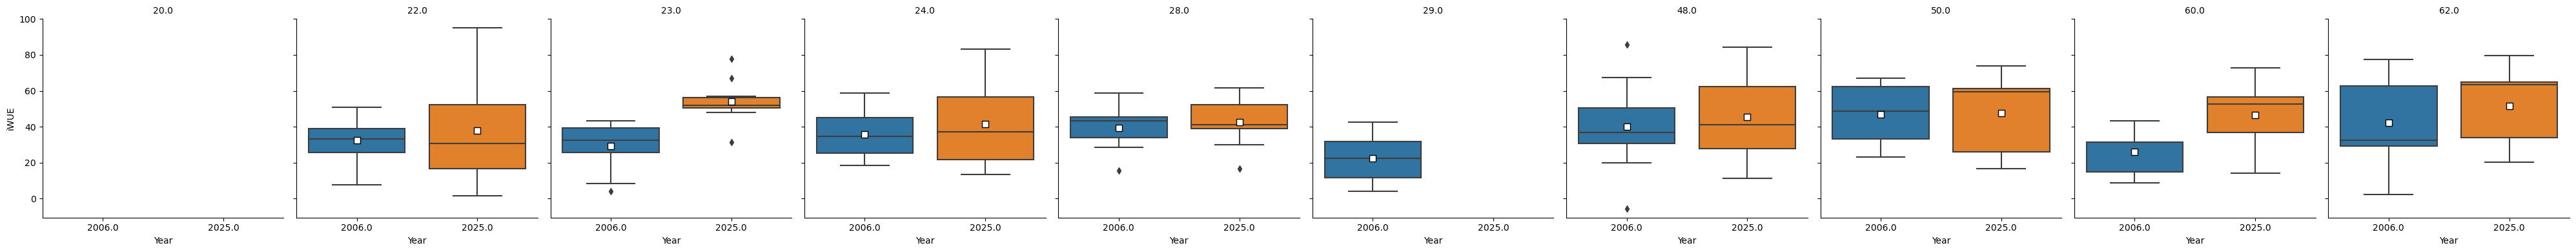

In [15]:
df["Plot"] = (
    df["Plot"]
    .astype(str)
    .str.replace("p", "", regex=False)
)

df["Plot"] = df["Plot"].astype("float64")

df.to_excel("test.xlsx")

g = sns.catplot(
    data=df,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Plot",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

for ax in g.axes.flat:
    # obtener el valor de Elevation de este subplot
    plot = ax.get_title().split(" = ")[-1]

    subset = df[df["Plot"].astype(str) == plot]

    means = subset.groupby("Year")["iWUE (μmol/mol)"].mean()

    # posiciones en x (0,1,2,...)
    x_positions = range(len(means))

    ax.scatter(
        x_positions,
        means,
        color="white",
        edgecolor="black",
        marker="s",  # cuadrado
        s=60,
        zorder=5
    )

g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

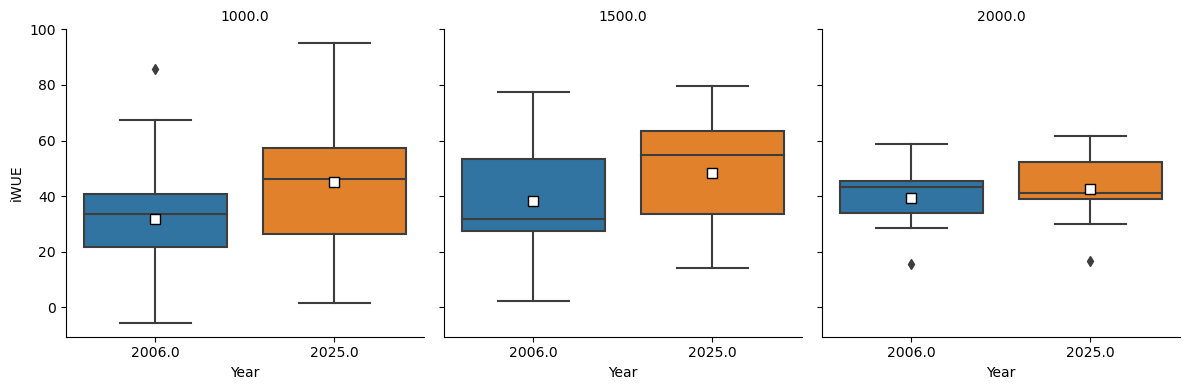

In [16]:
import elevation_dict
%run elevation_dict
df["Site"]="Galeras"
df["Elevation"] = df.set_index(["Site", "Plot"]).index.map(elevation_dict)
g = sns.catplot(
    data=df,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Elevation",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)
# Añadir media
for ax in g.axes.flat:
    # obtener el valor de Elevation de este subplot
    elev = ax.get_title().split(" = ")[-1]

    subset = df[df["Elevation"].astype(str) == elev]

    means = subset.groupby("Year")["iWUE (μmol/mol)"].mean()

    # posiciones en x (0,1,2,...)
    x_positions = range(len(means))

    ax.scatter(
        x_positions,
        means,
        color="white",
        edgecolor="black",
        marker="s",  # cuadrado
        s=60,
        zorder=5
    )

g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

In [17]:
df.head(3)

,Ci,Ci/Ca,Plot,Plot_,Sample ID,TreeID,Type,Type 2,Year,[C]%,...,iWUE (μmol/mol),new_TreeID,numeroCampo,old_treeID,sample-ID,δ13C (‰ v.s.V-PDB),δ15N (‰ v.s. V-PDB),△13C_cell,Site,Elevation
0,312.768866,0.818574,23.0,NaN,p23-557,557,leaf pulverized,NaN,2006.0,0.455530,...,43.325709,NaN,NaN,557,p23-557,-29.289590,1.960678,21.643520,Galeras,1000.0
1,315.228277,0.825011,23.0,NaN,p23-557,557,leaf pulverized,NaN,2006.0,43.360479,...,41.788577,NaN,NaN,557,p23-557,-29.427788,1.960678,21.788990,Galeras,1000.0
2,320.496034,0.838797,22.0,NaN,p22-550,550,leaf pulverized,NaN,2006.0,0.474114,...,38.496229,NaN,NaN,550,p22-550,-29.723659,4.370000,22.100569,Galeras,1000.0


# Unir con la base de datos completa para añadir informacion adicional

In [18]:
### HELP
df_filtrado = df
df_filtrado["Year"] = df_filtrado["Year"].astype("Float64")

df_2006 = df_filtrado[df_filtrado["Year"] == 2006.0]
print(len(df_2006)) #73
df_2025 = df_filtrado[df_filtrado["Year"] == 2025.0]
print(len(df_2025)) #77

### HELP: USAR BASE GRANDE O RASGOS. Base grande eliminar los x y y de los datos para evitar problemas. 
base_grade = base_grande[["treeID","new ID 2024","family","JH herbarium collections", "genus","species"]]
base_grande = base_grande[~base_grande["treeID"].isin(["x", "y"])]
base_grande["treeID"] = base_grande["treeID"].replace("", np.nan)
base_grande["treeID"] = base_grande["treeID"].astype("Float64")

df_2006["old_treeID"] = df_2006["old_treeID"].astype("Float64")
merge_2006 = pd.merge(df_2006,base_grande, left_on = ["old_treeID"], right_on = ["treeID"], how = "left") #left. Prioridad a los isotopos 
merge_2006.to_excel("2006.xlsx")

df_2025["new_TreeID"] = df_2025["new_TreeID"].astype("Float64")

base_grande["new ID 2024"] = base_grande["new ID 2024"].astype("Float64")
merge_2025 = pd.merge(df_2025,base_grande, left_on = ["new_TreeID"], right_on = ["new ID 2024"], how = "left") #left. Prioridad a los isotopos 
merge_2025.to_excel("2025.xlsx")
###
Keep = ["Plot_x","family","genus","species","PlotID","treeID","new ID 2024",nameC_cellulose,named13C_cellulose,"Sample ID","Year",
        "[N]","[C_b]%","δ15N (‰ v.s. V-PDB)","bulk_δ13C (‰ v.s.V-PDB)",
        "JH herbarium collections","Type","Site","Elevation"]

merge_2006 = merge_2006[Keep]
merge_2025 = merge_2025[Keep]

all = pd.concat([merge_2006,merge_2025])
all = all.sort_values(by=["Plot_x","new ID 2024"])
all = all.rename(columns={"Plot_x":"Plot","new ID 2024":"new_TreeID","treeID":"old_treeID","Sample ID":"Sample-ID"})
all.to_excel("iWUE_Galeras.xlsx")


117
81


C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16960\519203648.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2006["old_treeID"] = df_2006["old_treeID"].astype("Float64")
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16960\519203648.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025["new_TreeID"] = df_2025["new_TreeID"].astype("Float64")
